In [ ]:
import numpy as np
import pandas as pd

# 1. Get the data. Here we generate the data

# set random seed so that we generate the same random numbers everytime we run the code
np.random.seed(42) 

n_samples = 100  # number of samples we are working with

# generate the features(x)
size = np.random.randint(800, 3000, n_samples)

bedrooms = np.random.randint(1, 15 , n_samples)

bathrooms = np.random.randint(1, 4, n_samples)


# price = B1 * size + B2 * bedrooms + B3 * bathrooms + B0
# generate price where B1 = 200, B2 = 50000, B3 = 10000 and B0 = a random number following the normal distribution
price = 200 * size +  50000 * bedrooms +  10000 * bathrooms + np.random.normal(0, 50000, n_samples)

# create a data frame
df = pd.DataFrame({
    'size' : size,
    'bedrooms' : bedrooms,
    'bathrooms' : bathrooms,
    'price' : price
})

print(df.head())
print(df.info())

   size  bedrooms  bathrooms         price
0  1660        10          1  7.451812e+05
1  2094        10          2  8.964321e+05
2  1930        12          2  1.074222e+06
3  1895        13          3  1.117601e+06
4  2438         3          3  6.489440e+05
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   size       100 non-null    int32  
 1   bedrooms   100 non-null    int32  
 2   bathrooms  100 non-null    int32  
 3   price      100 non-null    float64
dtypes: float64(1), int32(3)
memory usage: 2.1 KB
None


<Axes: >

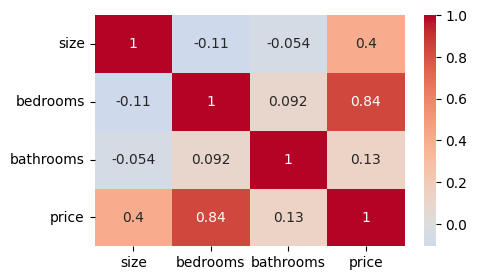

In [3]:
# 2. Preprocess the data(clean, preprocess and visualize)
# The data is clean so we just visualize it

# visualize the data
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

In [4]:
# 3. Separate the data
X = df[['size', 'bedrooms', 'bathrooms']]
y = df['price']

In [ ]:
# split the data - we use 80% training data and 20% test data. 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# printing statements
print(f'Training data: {len(X_train)}')
print(f'Testing data: {len(X_test)}')

Training data: 80
Testing data: 20


In [6]:
# 4. Select algorithm to use. 
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [7]:
# 5. Train data
model.fit(X_train, y_train)

print('Model trained')

Model trained


In [8]:
# 6. Make predictions on test data
y_pred = model.predict(X_test)

# difference between our actual and predicted value
comparison = pd.DataFrame({
    'Actual': y_test[:5],
    'Predicted' : y_pred[:5],
    'Difference' : np.round(y_test[:5] - y_pred[:5], 2)
})

print(comparison)

          Actual     Predicted  Difference
83  7.079103e+05  8.277375e+05  -119827.16
53  1.062135e+06  1.044058e+06    18076.93
70  8.344322e+05  8.329438e+05     1488.44
45  5.142483e+05  5.321981e+05   -17949.73
44  1.225329e+06  1.256415e+06   -31085.56


In [9]:
# 7. Evaluate the model

from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(f'mse = {mse:.2f}')

rmse = root_mean_squared_error(y_test, y_pred)
print(f'rmse = {rmse:.2f}')

r2 = r2_score(y_test, y_pred)
print(f'r2 score = {r2:.2f}')

mse = 3434173895.25
rmse = 58601.83
r2 score = 0.93
